# Vertical integration: RNA + ATAC, every method

This notebook runs every method that has a variant for vertical RNA + ATAC on `D27mini_vertical`: MIRA, MOFA2, Matilda, Multigrate, Seurat_WNN, UINMF, UnitedNet, VIMCCA, iPOLNG, moETM, scMDC, scMM, scMVP and scMoMaT. The [tutorial](https://dsichang.github.io/scMultiBench/tutorials/vertical_rna_atac/) explains each step and runs scMM and VIMCCA only.

Methods run on Linux. The environments are 14 envs, 39.8 GB to download on a CPU host, 46.5 GB on a GPU host.

## 1. Install

This cell installs `multibench-sc`. It keeps the numpy and pandas that are already installed, so Colab needs no restart.

<details>
<summary>Details</summary>

On Colab, choose a GPU runtime before you run the notebook: Runtime -> Change runtime type -> T4 GPU. On a CPU runtime, an environment that has a smaller CPU build gets that build, and training methods run slower.

</details>

In [1]:
import numpy, pandas
%pip install -q multibench-sc numpy=={numpy.__version__} pandas=={pandas.__version__}

Note: you may need to restart the kernel to use updated packages.


## 2. Download the data and the environments

In [2]:
import pandas as pd
import multibench as mtb

mtb.data.fetch("D27mini_vertical")

PosixPath('/tmp/mbverify/home/.cache/multibench/data')

In [3]:
METHODS = ["MIRA", "MOFA2", "Matilda", "Multigrate", "Seurat_WNN", "UINMF",
           "UnitedNet", "VIMCCA", "iPOLNG", "moETM", "scMDC", "scMM", "scMVP",
           "scMoMaT"]
envs = mtb.env.install(METHODS, dry_run=False)
pd.DataFrame(envs)[["env", "methods", "state"]]

,env,methods,state
0,MOFA2_env,[MOFA2],have
1,env_moETM,[moETM],have
2,matilda,[Matilda],have
3,scmb_ipolng2,[iPOLNG],have
4,scmb_mira,[MIRA],have
5,scmb_multigrate2,[Multigrate],have
6,scmb_r,[UINMF],have
7,scmb_scmdc,[scMDC],have
8,scmb_scmm2,[scMM],have
9,scmb_scmvp4,[scMVP],have


## 3. Run the methods

MIRA and Seurat_WNN return a neighbour graph, not an embedding. The package scores embeddings, so their rows have the status `RUN_OK_NO_EMBEDDING` and no scores, and the figure leaves them out.

In [4]:
res = mtb.run_all("D27mini_vertical", "vertical", methods=METHODS,
                  out_dir="out/D27mini_vertical_all")
res.summary

[run_all] 15 more rows need files this folder does not have. mtb.scan shows them.


[run_all] MIRA (vertical/D27mini_vertical) ...


[run_all]   MIRA needs about 2,000 genes and several thousand cells. It failed on 1,000 genes and on 1,500 cells.


[run_all]   -> RUN_OK_NO_EMBEDDING (243.1s)


[run_all] MOFA2 (vertical/D27mini_vertical) ...


...

[run_all]   scMVP drops every peak open in more than 10% of the cells and fails when none is left.


[run_all]   -> CHAIN_OK (79.6s) ARI 0.802


[run_all] scMoMaT (vertical/D27mini_vertical) ...


[run_all]   -> CHAIN_OK_GRAPH_METHOD (66.8s) ARI 0.368


,method,status,run_sec,output_kind,emb_shape,n_tunable,label_order,label_order_confidence,batch_source,n_batches,ARI,NMI,ASW,iASW,iF1,cLISI,label_order_note,caveat,reason
0,MIRA,RUN_OK_NO_EMBEDDING,243.1,graph,None,8,None,NaN,None,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,not scored,"MIRA needs about 2,000 genes and several thous...",
1,MOFA2,CHAIN_OK,92.4,embedding,"[5000, 20]",0,cty.csv,NaN,None,1,0.5876,0.7178,0.5625,0.5938,0.8375,0.9912,single ordering,,
2,Matilda,CHAIN_OK,21.9,embedding,"[5000, 100]",10,cty.csv,NaN,None,1,0.8758,0.8709,0.6750,0.6828,0.9385,0.9989,single ordering,,
3,Multigrate,CHAIN_OK,78.2,embedding,"[5000, 15]",3,cty.csv,NaN,None,1,0.4803,0.6312,0.5510,0.5669,0.6458,0.9824,single ordering,,
4,Seurat_WNN,RUN_OK_NO_EMBEDDING,293.7,graph,None,0,None,NaN,None,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,not scored,,
5,UINMF,CHAIN_OK,33.3,embedding,"[5000, 30]",0,cty.csv,NaN,None,1,0.8536,0.8308,0.5923,0.6483,0.8879,0.9922,single ordering,,
6,UnitedNet,CHAIN_OK,86.8,embedding,"[5000, 64]",1,cty.csv,NaN,None,1,0.9546,0.9757,0.8629,0.8480,0.9954,1.0000,single ordering,,
7,VIMCCA,CHAIN_OK,19.6,embedding,"[5000, 8]",0,cty.csv,NaN,None,1,0.4770,0.6201,0.5355,0.5460,0.6354,0.9632,single ordering,,
8,iPOLNG,CHAIN_OK,120.1,embedding,"[5000, 20]",0,cty.csv,NaN,None,1,0.6994,0.7501,0.6278,0.6479,0.7224,0.9857,single ordering,,
9,moETM,CHAIN_OK,13.1,embedding,"[5000, 100]",0,cty.csv,NaN,None,1,0.6830,0.7529,0.5355,0.5718,0.7390,0.9618,single ordering,,


## 4. Plot

`res.plot()` draws the scores as a bubble table. Circle size shows the rank within a column, and bigger is better. The fill compares a value with the other rows in the same column.

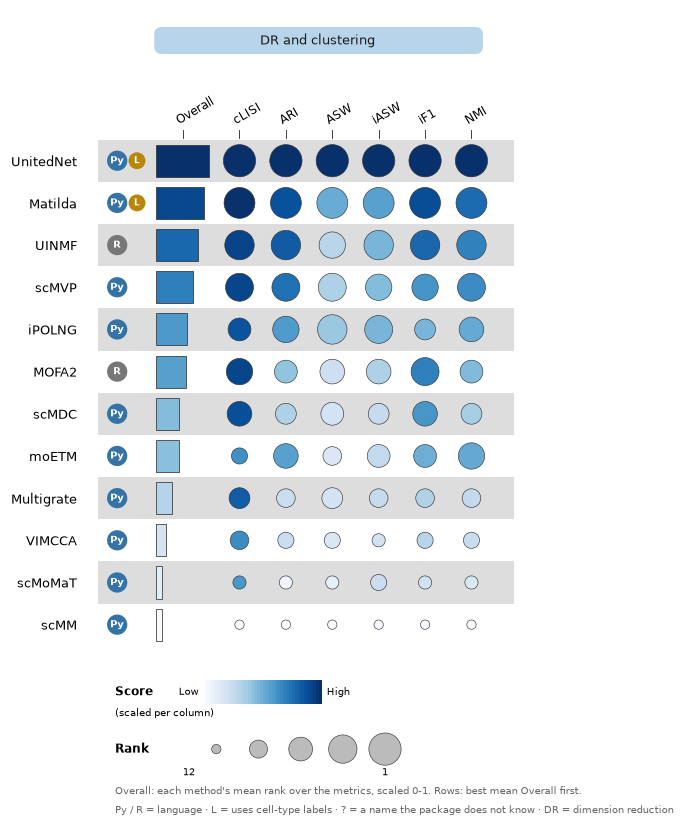

In [5]:
res.plot()